# Objective : Classify skin disease using tranfer learning concept

## Installing required libraries

In [20]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from tensorflow.keras.layers import Flatten,Dense,GlobalAveragePooling2D
from keras.applications.vgg16 import VGG16
import matplotlib.pyplot as plt


In [13]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/umairshahab/dermnet-skin-diesease-images/dataset_categorized_final_split/train',
    labels ='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(170,170)
)
test_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/umairshahab/dermnet-skin-diesease-images/dataset_categorized_final_split/test',
    labels ='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(170,170)
)

Found 24855 files belonging to 23 classes.
Found 4317 files belonging to 23 classes.


In [14]:
num_classes=len(train_ds.class_names)

In [15]:
# normalization of images in [0,1] or [-1,1] because this is what most models accept as image to be in.
normalization_layer = keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

####  Full batch looks like: (64, 170, 170, 3)   →   64 images per batch of images size 170*170*3

## ~Feature Extraction

In [16]:
conv_b = VGG16(
    weights='imagenet',
    include_top=False, 
    input_shape=(170,170,3)
)

In [17]:
conv_b.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 170, 170, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 170, 170, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 170, 170, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 85, 85, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 85, 85, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 85, 85, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 42, 42, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 42, 42, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 42, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 42, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 21, 21, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 21, 21, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 21, 21, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
conv_b.trainable=False

#### All 14 layers of VGG16's convolutional blocks are now frozen .Their weights will not update during backpropagation .They will only act as a fixed feature extractor

In [25]:
model = Sequential()
model.add(conv_b)
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation='relu'))
model.add(Dense(num_classes,activation='softmax'))

In [26]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,851,927 (56.66 MB)

 Trainable params: 137,239 (536.09 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [27]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [28]:
# history =model.fit(train_ds,epoch = 10 ,test_ds)  ---- wrong
history =model.fit(train_ds,epochs= 10 ,validation_data = test_ds)

Epoch 1/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 120s 303ms/step - accuracy: 0.1749 - loss: 2.7840 - val_accuracy: 0.1110 - val_loss: 2.9060
Epoch 2/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 115s 295ms/step - accuracy: 0.2274 - loss: 2.6217 - val_accuracy: 0.1471 - val_loss: 2.8424
Epoch 3/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 115s 295ms/step - accuracy: 0.2452 - loss: 2.5536 - val_accuracy: 0.1527 - val_loss: 2.8464
Epoch 4/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 115s 295ms/step - accuracy: 0.2591 - loss: 2.5013 - val_accuracy: 0.1612 - val_loss: 2.8506
Epoch 5/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 115s 295ms/step - accuracy: 0.2675 - loss: 2.4666 - val_accuracy: 0.1543 - val_loss: 2.8407
Epoch 6/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 115s 295ms/step - accuracy: 0.2778 - loss: 2.4278 - val_accuracy: 0.1661 - val_loss: 2.8355
Epoch 7/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 115s 295ms/step - accuracy: 0.2840 - loss: 2.4007 - val_accuracy: 0.1705 - val_loss: 2.8172
Epoch 8/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 115s 295ms/step - accuracy: 0.2911 -

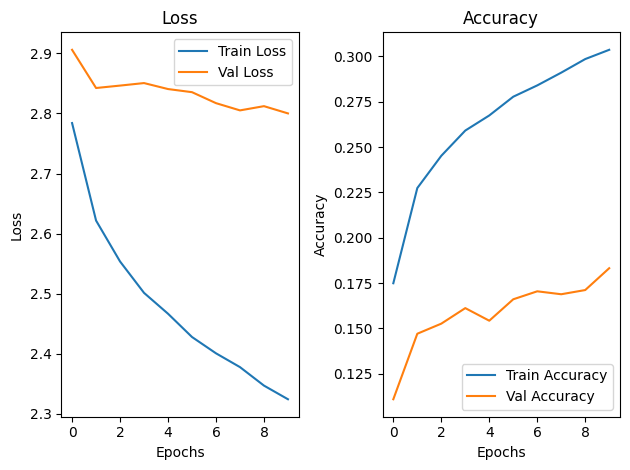

In [29]:
fig , ax =plt.subplots(1,2)
# Loss plot
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy plot
ax[1].plot(history.history['accuracy'], label='Train Accuracy')
ax[1].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

## ~Fine Tuning

In [31]:
conv_nb= VGG16(
    weights='imagenet',
    input_shape=(170,170,3),
    include_top=False
)

In [35]:
conv_nb.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 170, 170, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 170, 170, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 170, 170, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 85, 85, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 85, 85, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 85, 85, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 42, 42, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 42, 42, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 42, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 42, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 21, 21, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 21, 21, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 21, 21, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# freeze the layer you dont wanted to train .
# we need to train the layer from block4_conv1 and onwards
conv_nb.trainable = True

set_trainable = False   # flag to encouter the layer from which you want to train the model

for layer in conv_nb.layers:
    if layer.name == 'block4_conv1':
        set_trainable= True
    if set_trainable:
        layer.trainable= True # mark the layers which you need to train
    else:
        layer.trainable=False
        
for layers in conv_nb.layers:
    print(layers.name,layers.trainable)

input_layer_5 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 True
block4_conv2 True
block4_conv3 True
block4_pool True
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [34]:
conv_nb.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 170, 170, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 170, 170, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 170, 170, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 85, 85, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 85, 85, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 85, 85, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 42, 42, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 42, 42, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 42, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 42, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 21, 21, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 21, 21, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 21, 21, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_f = Sequential()
model_f.add(conv_nb)
model_f.add(GlobalAveragePooling2D())
model_f.add(Dense(256,activation='relu'))
model_f.add(Dense(num_classes,activation='softmax'))

In [39]:
model_f.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,851,927 (56.66 MB)

 Trainable params: 13,116,439 (50.04 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [40]:
# compilation of model
model_f.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [41]:
history_f = model_f.fit(train_ds,epochs= 10 ,validation_data = test_ds)

Epoch 1/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 184s 429ms/step - accuracy: 0.1973 - loss: 2.7362 - val_accuracy: 0.1682 - val_loss: 2.8014
Epoch 2/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 158s 407ms/step - accuracy: 0.2707 - loss: 2.4671 - val_accuracy: 0.1073 - val_loss: 3.1135
Epoch 3/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 159s 408ms/step - accuracy: 0.3091 - loss: 2.3224 - val_accuracy: 0.1353 - val_loss: 2.9699
Epoch 4/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 158s 407ms/step - accuracy: 0.3454 - loss: 2.2078 - val_accuracy: 0.1846 - val_loss: 2.7729
Epoch 5/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 158s 406ms/step - accuracy: 0.3673 - loss: 2.1122 - val_accuracy: 0.1594 - val_loss: 2.8909
Epoch 6/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 158s 405ms/step - accuracy: 0.3952 - loss: 2.0242 - val_accuracy: 0.2126 - val_loss: 2.7158
Epoch 7/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 158s 407ms/step - accuracy: 0.4172 - loss: 1.9425 - val_accuracy: 0.1867 - val_loss: 2.8727
Epoch 8/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 159s 408ms/step - accuracy: 0.4373 -

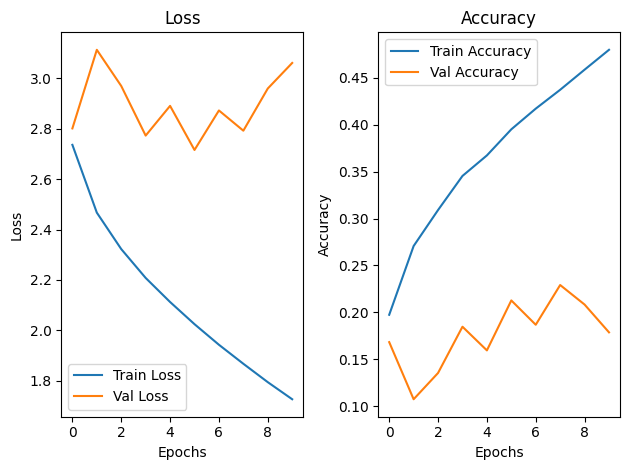

In [44]:
fig , ax =plt.subplots(1,2)
# Loss plot
ax[0].plot(history_f.history['loss'], label='Train Loss')
ax[0].plot(history_f.history['val_loss'], label='Val Loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy plot
ax[1].plot(history_f.history['accuracy'], label='Train Accuracy')
ax[1].plot(history_f.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

## Conclusion

The model learns correctly — loss decreases and accuracy improves across both
Feature Extraction and Fine Tuning phases, confirming the transfer learning
pipeline works as intended.

The accuracy is not high due to the following reasons:

- **Domain Mismatch** — VGG16 was trained on general ImageNet images, not medical data
- **Dataset Complexity** — Many skin diseases look visually similar making classification hard
- **Outdated Architecture** — VGG16 (2014) is heavy and less accurate than modern models
- **No Data Augmentation** — Model had limited ability to generalize
- **Small Image Size** — Resizing to (170,170) may have lost fine-grained skin details

The primary goal of this project was to demonstrate understanding of the
Transfer Learning pipeline, which has been achieved successfully.